In [ ]:
import pandas as pd

# Load datasets
train_df = pd.read_csv("Titanic_train.csv")
test_df = pd.read_csv("Titanic_test.csv")

# Preview
print(train_df.shape)
train_df.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


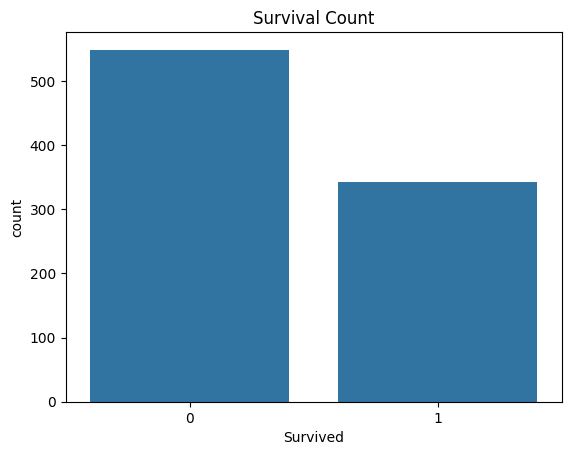

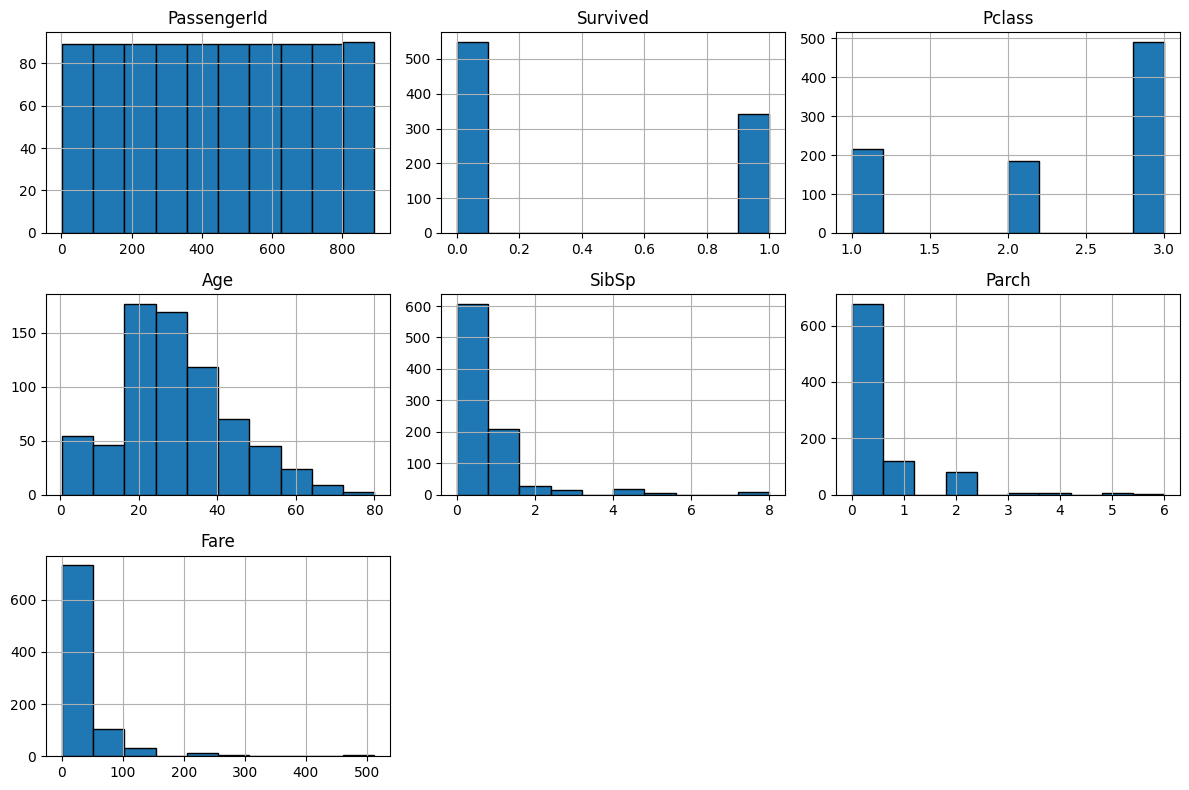

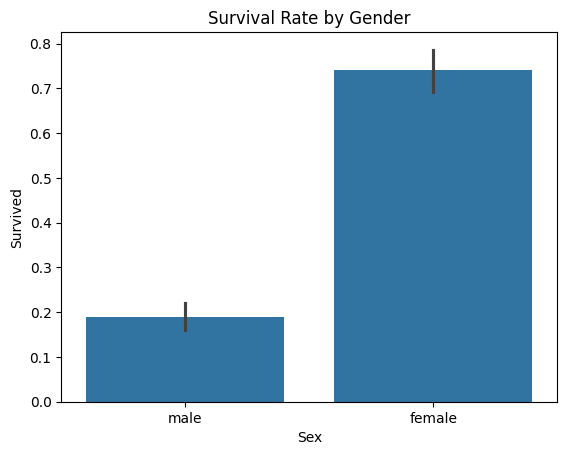

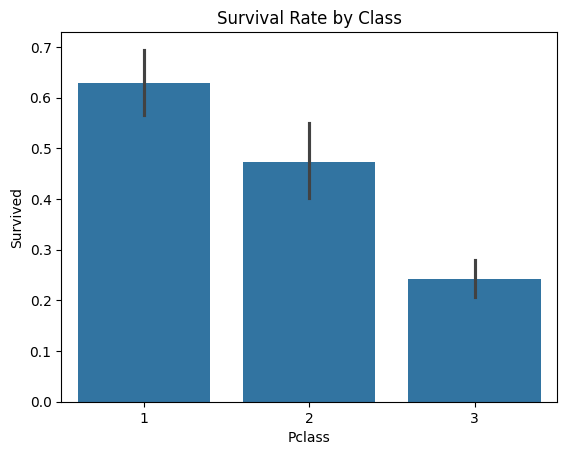

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check missing values
print(train_df.isnull().sum())

# Visualize survival distribution
sns.countplot(data=train_df, x='Survived')
plt.title("Survival Count")
plt.show()

# Histograms for numerical features
train_df.hist(figsize=(12, 8), edgecolor='black')
plt.tight_layout()
plt.show()

# Survival rate by gender
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title("Survival Rate by Gender")
plt.show()

# Survival by Pclass
sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title("Survival Rate by Class")
plt.show()


In [ ]:
# Fill missing Age with median
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)

# Fill Embarked with mode
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)

# Drop unnecessary columns
train_df.drop(['Cabin', 'Ticket', 'Name', 'PassengerId'], axis=1, inplace=True)

# Convert categorical variables
train_df = pd.get_dummies(train_df, columns=['Sex', 'Embarked'], drop_first=True)


/tmp/ipython-input-3-2745996293.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
/tmp/ipython-input-3-2745996293.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
from sklearn.model_selection import train_test_split

X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report

lgb_model = lgb.LGBMClassifier()
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_val)

print("🔹 LightGBM Classification Report")
print(classification_report(y_val, y_pred_lgb))


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000503 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 206
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)

print("🔹 XGBoost Classification Report")
print(classification_report(y_val, y_pred_xgb))


🔹 XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:55:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

lgb_metrics = evaluate_model(y_val, y_pred_lgb)
xgb_metrics = evaluate_model(y_val, y_pred_xgb)

# Display results
print("✅ LightGBM:", lgb_metrics)
print("✅ XGBoost:", xgb_metrics)


✅ LightGBM: {'Accuracy': 0.7988826815642458, 'Precision': 0.7538461538461538, 'Recall': 0.7101449275362319, 'F1-Score': 0.7313432835820896}
✅ XGBoost: {'Accuracy': 0.8044692737430168, 'Precision': 0.7575757575757576, 'Recall': 0.7246376811594203, 'F1-Score': 0.7407407407407407}


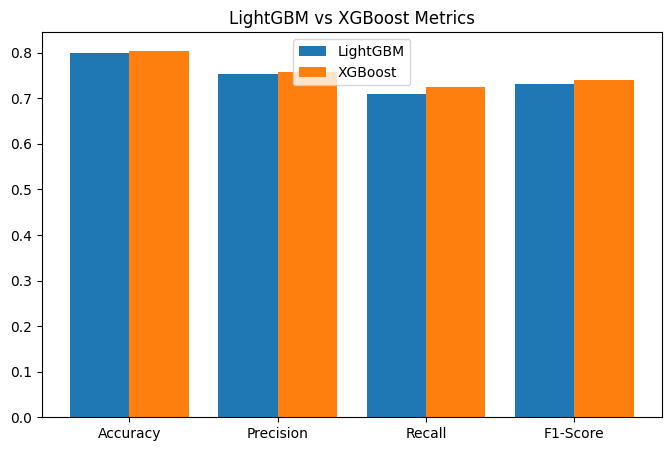

In [ ]:
import matplotlib.pyplot as plt

labels = list(lgb_metrics.keys())
lgb_values = list(lgb_metrics.values())
xgb_values = list(xgb_metrics.values())

x = range(len(labels))
plt.figure(figsize=(8, 5))
plt.bar(x, lgb_values, width=0.4, label='LightGBM', align='center')
plt.bar([i + 0.4 for i in x], xgb_values, width=0.4, label='XGBoost', align='center')
plt.xticks([i + 0.2 for i in x], labels)
plt.title("LightGBM vs XGBoost Metrics")
plt.legend()
plt.show()
